In [8]:
using LinearAlgebra
using Random
using Plots        
using BenchmarkTools 

include("../src/gauss-elim.jl")
include("../src/cholesky-factors.jl")
include("../src/ridge-forecasting.jl")


fast_ridge (generic function with 1 method)

In [9]:
#(a)Implementations:
Random.seed!(2026) 
T=1000
d=30
X=randn(T, d)                   
true_beta=randn(d)         
noise=0.5*randn(T)           
Y= X*true_beta + noise       
gamma= 1/sqrt(T)    

println("Run Naive Implementation")
Y_hat_naive = naive_ridge(X, Y, gamma)
println("Run Fast Implementation")
Y_hat_fast = fast_ridge(X, Y, gamma)
max_diff = maximum(abs.(Y_hat_naive - Y_hat_fast))

println("The maximum prediction difference is : ", max_diff)
println("Whether the two outputs are the same :", isapprox(Y_hat_naive, Y_hat_fast, atol=1e-8))

Run Naive Implementation
Run Fast Implementation
The maximum prediction difference is : 2.5588420271560608e-12
Whether the two outputs are the same :true


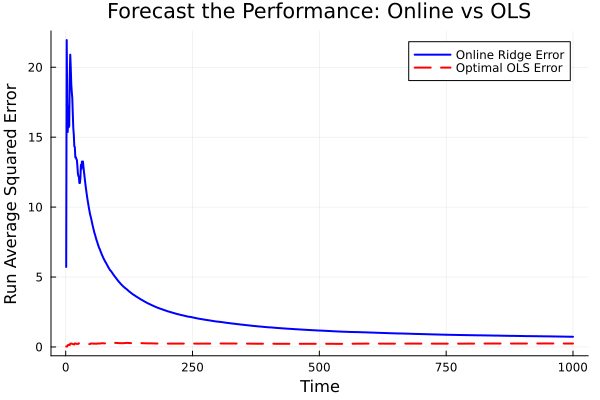

In [11]:
# (b) Forecasting Performance
ridge_error=(Y_hat_fast .- Y).^2
avg_ridge=cumsum(ridge_error)./(1:T)
beta_OLS = (X'*X)\(X'*Y)
Y_hat_OLS = X*beta_OLS
ols_errors = (Y_hat_OLS.-Y).^2
avg_ols = cumsum(ols_errors) ./ (1:T)

plot(1:T,avg_ridge, label="Online Ridge Error", 
     linewidth=2, color=:blue, xlabel="Time", 
     ylabel="Run Average Squared Error", 
     title="Forecast the Performance: Online vs OLS")
plot!(1:T, avg_ols, label="Optimal OLS Error", 
      linewidth=2, linestyle=:dash, color=:red)

(b) Forecasting Performance:
The online ridge error is initially high， bcs the model has seen very few data points. However, as time $t$ increases and more data is processed, the online prediction error rapidly decreases and asymptotically converges toward the optimal OLS error.

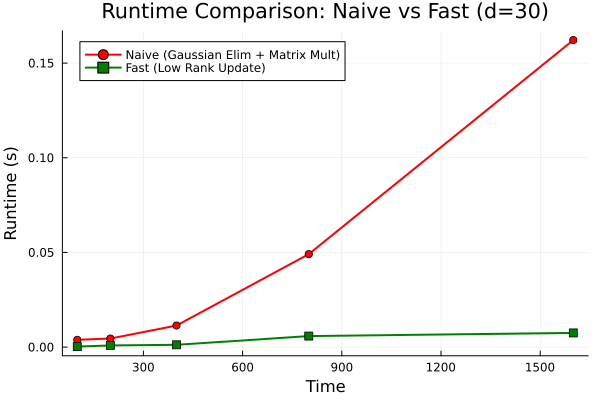

In [13]:
#(c) Timing
Ts= [100, 200, 400, 800, 1600]
d_fixed= 30
time_naive=Float64[]
time_fast=Float64[]

for t_val in Ts
    X_temp=randn(t_val, d_fixed)
    Y_temp=X_temp * true_beta + 0.5*randn(t_val)
    g_temp=1 / sqrt(t_val)
    t_n= @elapsed naive_ridge(X_temp, Y_temp, g_temp)
    t_f= @elapsed fast_ridge(X_temp, Y_temp, g_temp)
    push!(time_naive, t_n)
    push!(time_fast, t_f)
end

plot(Ts, time_naive, label="Naive (Gaussian Elim + Matrix Mult)", 
     marker=:circle, linewidth=2, color=:red,
     xlabel="Time", ylabel="Runtime (s)", 
     title="Runtime Comparison: Naive vs Fast (d=30)", legend=:topleft)
plot!(Ts, time_fast, label="Fast (Low Rank Update)", 
      marker=:square, linewidth=2, color=:green)

(c) Timing:

Yes, the empirical timing aligns perfectly with the expected asymptotic runtimes:

Naive Implementation:
Its asymptotic runtime is $O(T^2 d^2 + T d^3)$, which is clearly reflected in the plot as a quadratic (parabolic) growth curve with respect to $T$.

Fast Implementation: Uses low rank updates and forward/backward substitution, requiring only $O(T d^2)$ time. This is reflected in the plot as a flat, linear growth curve, running orders of magnitude faster than the naive approach.